<a href="https://colab.research.google.com/github/shaswath-29/EDA_LABORATORY_ASSIGNMENT/blob/Exp6_18.08.2026/MultivariateAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/content/WineQT.csv")

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
print(df.head(3))

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  


In [5]:
print(df.tail(3))

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645         0.12             2.0      0.075   

      free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
1140                 32.0                  44.0  0.99490  3.45       0.58   
1141                 39.0                  51.0  0.99512  3.52       0.76   
1142                 32.0                  44.0  0.99547  3.57       0.71   

      alcohol  quality    Id  
1140     10.5        5  1594  
1141     11.2        6  1595  
1142     10.2        5  1597  


In [6]:
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [7]:
print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000             1.000000         

In [9]:
pd.isna(df).any()

,0
fixed acidity,False
volatile acidity,False
citric acid,False
residual sugar,False
chlorides,False
free sulfur dioxide,False
total sulfur dioxide,False
density,False
pH,False
sulphates,False


In [10]:
df['quality'].astype(str).str.isnumeric().value_counts()

,count
quality,
True,1143


In [11]:
df['quality'].loc[df['quality'].astype(str).str.isnumeric() == False]

,quality


In [12]:
price = df['quality'].loc[df['quality'] != '?']
print(price)

0       5
1       5
2       5
3       6
4       5
       ..
1138    6
1139    6
1140    5
1141    6
1142    5
Name: quality, Length: 1143, dtype: int64


In [13]:
pmean = price.astype(int).mean()
print("Mean =",pmean)

Mean = 5.657042869641295


In [14]:
df['price'] = price
df['price'].head(10)

,price
0,5
1,5
2,5
3,6
4,5
5,5
6,5
7,7
8,7
9,5


In [15]:
ph = df['pH']
phmean = ph.astype(float).mean()
df['pH'] = df['pH'].replace('?', phmean).astype(float)
df['pH'].head()

,pH
0,3.51
1,3.20
2,3.26
3,3.16
4,3.51


In [16]:
vamean = df['volatile acidity'].astype(float).mean()
df['volatile acidity'] = df['volatile acidity'].replace('?', vamean).astype(float)
print(f"Mean of 'volatile acidity': {vamean}")

Mean of 'volatile acidity': 0.5313385826771653


In [17]:
df['volatile acidity'].head()

,volatile acidity
0,0.70
1,0.88
2,0.76
3,0.28
4,0.70


In [18]:
mean_density = df["density"].mean()
median_density = df["density"].median()
mode_density = df["density"].mode()
print(f"Mean of density: {mean_density}")
print(f"Median of density: {median_density}")
print(f"Mode of density: {mode_density}")


Mean of density: 0.9967304111986001
Median of density: 0.99668
Mode of density: 0    0.9976
Name: density, dtype: float64


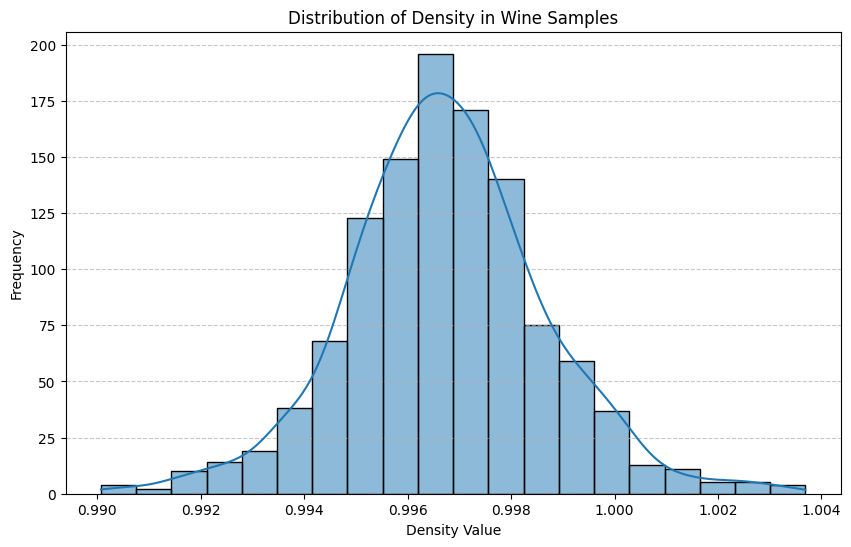

In [19]:
fig = plt.figure(figsize=(10, 6))
sns.histplot(df['density'], kde=True, bins=20)
plt.title('Distribution of Density in Wine Samples')
plt.xlabel('Density Value')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

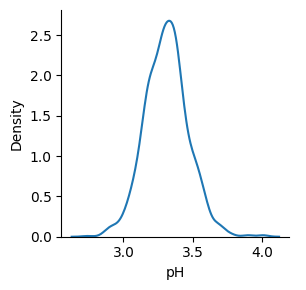

In [20]:
sns.FacetGrid(df).map(sns.kdeplot, "pH").add_legend()

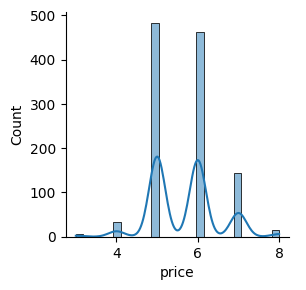

In [21]:
sns.FacetGrid(df).map(sns.histplot, "price", kde=True).add_legend()

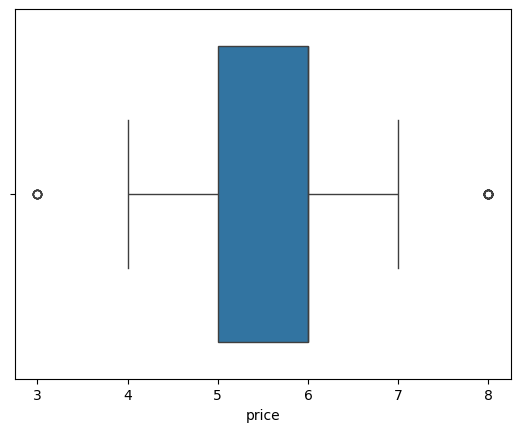

In [22]:
sns.boxplot(x="price",data=df)
plt.show()

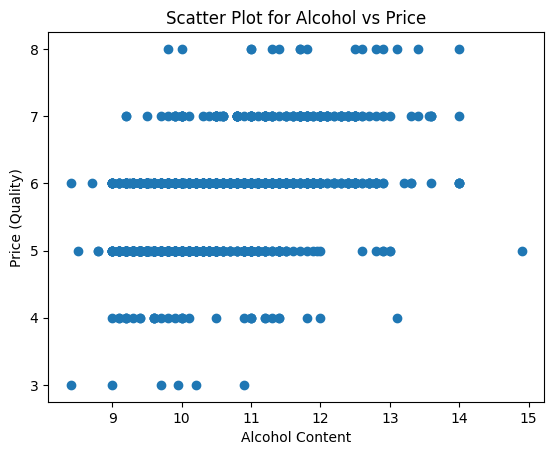

In [23]:
plt.scatter(df["alcohol"], df["price"])
plt.title("Scatter Plot for Alcohol vs Price")
plt.xlabel("Alcohol Content")
plt.ylabel("Price (Quality)")
plt.show()

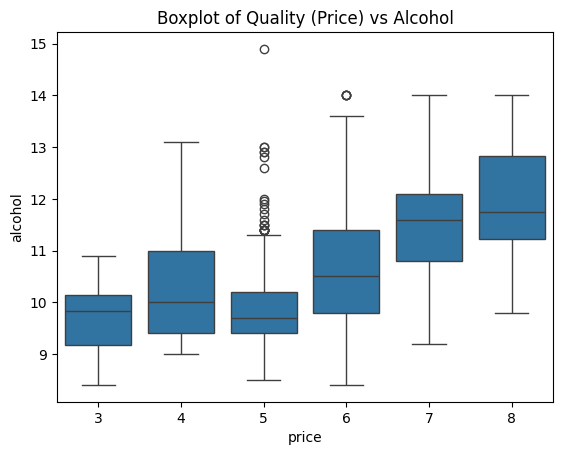

In [24]:
sns.boxplot(x="price", y="alcohol", data=df)
plt.title("Boxplot of Quality (Price) vs Alcohol")
plt.show()

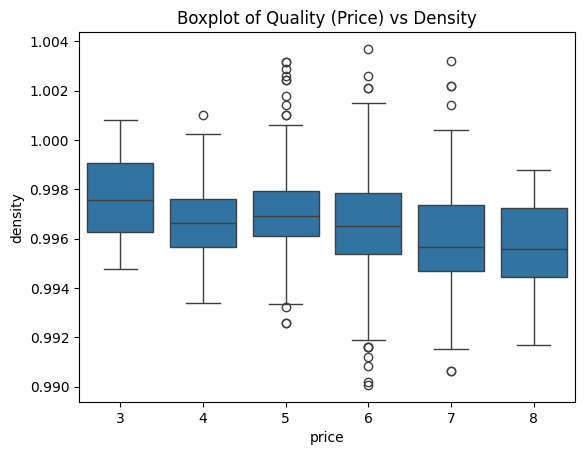

In [25]:
sns.boxplot(x="price", y="density", data=df)
plt.title("Boxplot of Quality (Price) vs Density")
plt.show()

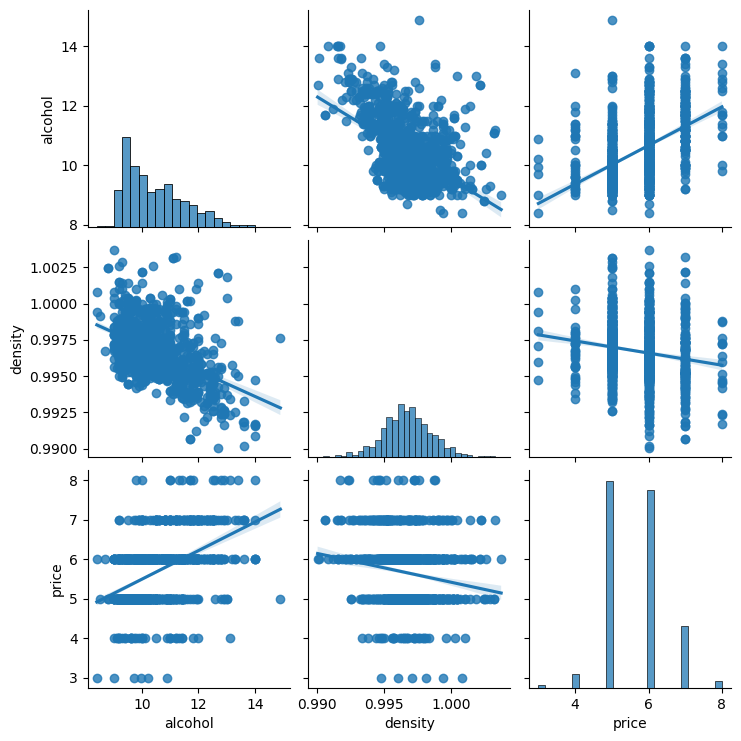

In [26]:
sns.pairplot(df, vars=['alcohol', 'density', 'price'], kind="reg")
plt.show()

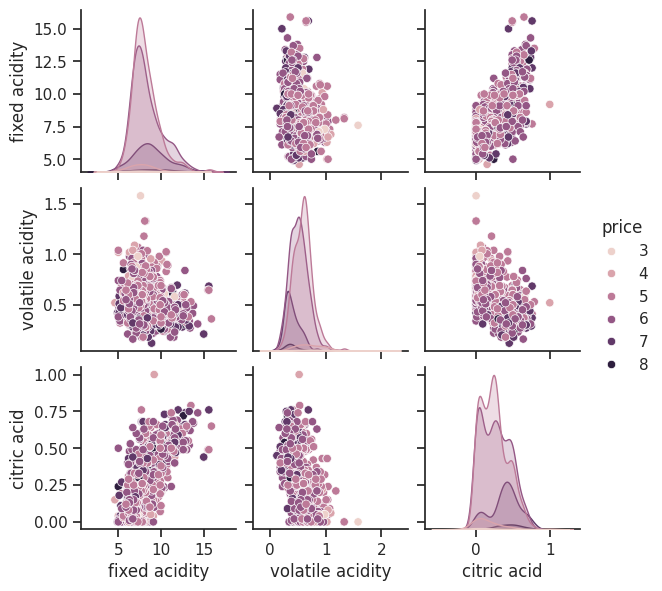

In [27]:
sns.set(style="ticks", color_codes=True)
sns.pairplot(df, height=2, vars=['fixed acidity', 'volatile acidity', 'citric acid'], hue="price")
plt.show()

In [28]:
from scipy import stats
corr = stats.pearsonr(df["price"], df["alcohol"])
print("p-value:\t", corr[1])
print("cor:\t\t", corr[0])

p-value:	 1.9246528151001656e-68
cor:		 0.4848662118085117


In [29]:
correlation = df.corr(method='pearson', numeric_only=True)
correlation

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,price
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826,0.121970
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892,-0.407394
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011,0.240821
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344,0.022002
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099,-0.124085
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268,-0.063260
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389,-0.183339
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926,-0.175208
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904,-0.052453
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954,0.257710


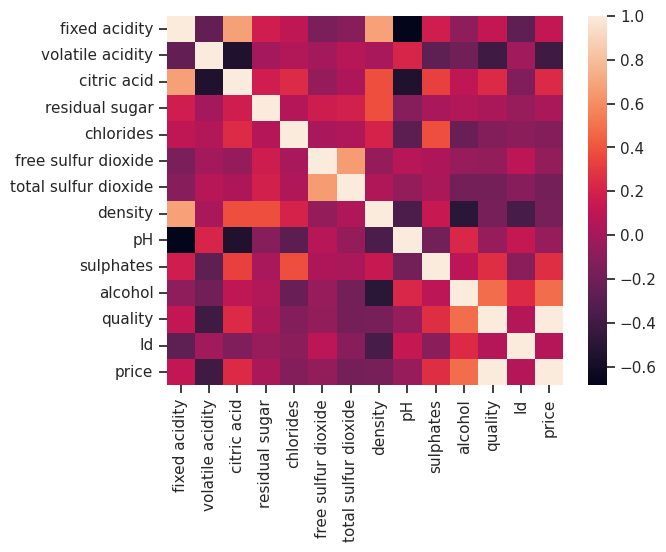

In [31]:
sns.heatmap(correlation, xticklabels=correlation.columns, yticklabels=correlation.columns)
plt.show()